# Week 6 — Inverted Pendulum (Cart-Pole) with DQN

The classic inverted pendulum problem: a pole is hinged on a cart, and the
only two actions are pushing the cart left or right. The goal is to keep the
pole upright against gravity and disturbances. This is Gymnasium's
`CartPole-v1`.

I used DQN rather than DDPG because the action space is discrete (two
actions) — DDPG is meant for continuous actions like torque control. The
environment counts as solved when the average reward over 100 consecutive
episodes is ≥ 475 (an episode is capped at 500 steps).


In [1]:
%matplotlib inline
import os
import warnings

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # quiet TensorFlow logs
warnings.filterwarnings("ignore")

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cycler import cycler

import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

np.random.seed(42)
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()  # reproducible runs

print("TensorFlow", tf.__version__, "| gymnasium", gym.__version__)

# plot styling: consistent palette, thin marks, recessive grid
COLORS = {"blue": "#2a78d6", "aqua": "#1baf7a", "yellow": "#eda100",
          "green": "#008300", "violet": "#4a3aa7", "red": "#e34948"}
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.grid": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": "#52514e", "xtick.color": "#898781",
    "ytick.color": "#898781", "text.color": "#0b0b0b",
    "lines.linewidth": 2.0,
    "axes.prop_cycle": cycler(color=list(COLORS.values())),
    "figure.figsize": (12, 5), "savefig.dpi": 150,
    "savefig.bbox": "tight", "legend.frameon": False,
})


def save_fig(fig, name):
    """Save a copy of the figure next to the notebook."""
    fig.savefig(name)
    print(f"saved plot -> {name}")


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


2026-07-08 19:16:59.541881: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783518419.553597   21849 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783518419.557099   21849 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783518419.566071   21849 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783518419.566086   21849 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783518419.566088   21849 computation_placer.cc:177] computation placer alr

TensorFlow 2.19.0 | gymnasium 1.3.0


## 1 — The environment

The state has 4 values: cart position and velocity, pole angle and angular
velocity. Actions: `0` = push left, `1` = push right. The reward is +1 for
every step the pole stays up; the episode ends when the pole tips past ±12°,
the cart leaves the track (|x| > 2.4 m) or 500 steps pass. A random policy
survives about 20 steps.


In [2]:
env = gym.make("CartPole-v1")          # training environment
eval_env = gym.make("CartPole-v1")     # separate env for greedy evaluation
N_OBS = env.observation_space.shape[0]
N_ACTIONS = env.action_space.n

print("State space: ", env.observation_space)
print("Action space:", env.action_space, "- 0: push LEFT, 1: push RIGHT")
print("Episode cap: ", env.spec.max_episode_steps,
      "steps | official solved threshold: avg reward >=",
      env.spec.reward_threshold, "over 100 consecutive episodes")

env.reset(seed=42)

rng_baseline = np.random.default_rng(0)
random_returns = []
for _ in range(50):
    obs, _ = env.reset()
    tot, done = 0.0, False
    while not done:
        obs, r, term, trunc, _ = env.step(int(rng_baseline.integers(2)))
        done = term or trunc
        tot += r
    random_returns.append(tot)
print(f"\nRandom policy over 50 episodes: survives "
      f"{np.mean(random_returns):.1f} +/- {np.std(random_returns):.1f} steps")


State space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2) - 0: push LEFT, 1: push RIGHT
Episode cap:  500 steps | official solved threshold: avg reward >= 475.0 over 100 consecutive episodes

Random policy over 50 episodes: survives 21.9 +/- 10.1 steps


saved plot -> 01_random_policy.png


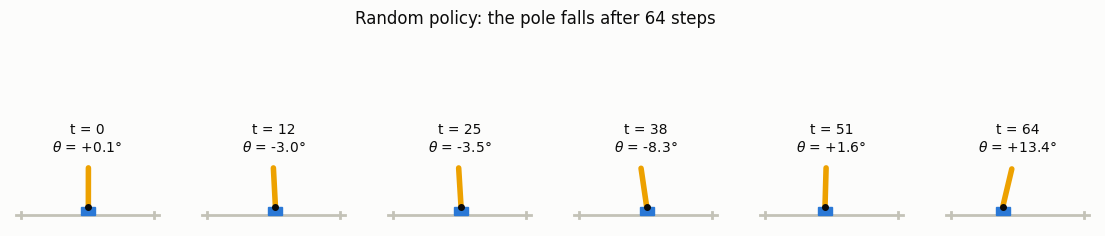

In [3]:
def rollout(policy, e=env, seed=None, kicks=None):
    """Run one episode; return the state trajectory (t, [x, xd, th, thd]).

    kicks = {step: delta_theta_dot} injects angular-velocity disturbances
    mid-episode (used for the robustness test in Section 5)."""
    obs, _ = e.reset(seed=seed)
    states, done = [np.array(e.unwrapped.state, dtype=float)], False
    while not done:
        obs, _, term, trunc, _ = e.step(policy(obs))
        if kicks and len(states) in kicks:
            s = np.array(e.unwrapped.state, dtype=float)
            s[3] += kicks[len(states)]
            e.unwrapped.state = s
            obs = s.astype(np.float32)
        states.append(np.array(e.unwrapped.state, dtype=float))
        done = term or trunc
    return np.array(states)


def draw_cartpole(ax, state, t=None):
    """Schematic cart-pole from a state vector (no render dependencies)."""
    x, _, th, _ = state
    ax.plot([-2.6, 2.6], [0, 0], color="#c3c2b7", linewidth=2, zorder=1)
    for b in (-2.4, 2.4):                       # track boundaries
        ax.plot([b, b], [-0.12, 0.12], color="#c3c2b7", linewidth=2)
    ax.add_patch(plt.Rectangle((x - 0.25, 0.0), 0.5, 0.3,
                               color=COLORS["blue"], zorder=2))
    tip = (x + 1.4 * np.sin(th), 0.3 + 1.4 * np.cos(th))
    ax.plot([x, tip[0]], [0.3, tip[1]], color=COLORS["yellow"], linewidth=4,
            solid_capstyle="round", zorder=3)
    ax.plot([x], [0.3], marker="o", color="#0b0b0b", markersize=4, zorder=4)
    ax.set_xlim(-2.8, 2.8)
    ax.set_ylim(-0.4, 2.0)
    ax.set_aspect("equal")
    ax.axis("off")
    if t is not None:
        ax.set_title(f"t = {t}\n$\\theta$ = {np.degrees(th):+.1f}°",
                     fontsize=10)


rng_rand = np.random.default_rng(1)
random_states = rollout(lambda obs: int(rng_rand.integers(2)), seed=5)

fig, axes = plt.subplots(1, 6, figsize=(14, 2.8))
for ax, i in zip(axes,
                 np.linspace(0, len(random_states) - 1, 6).astype(int)):
    draw_cartpole(ax, random_states[i], t=i)
fig.suptitle(f"Random policy: the pole falls after "
             f"{len(random_states) - 1} steps", y=1.15)
save_fig(fig, "01_random_policy.png")
plt.show()


## 2 — The agent: Double DQN

A small MLP (4 → 128 → 128 → 2) approximates Q(s, a), trained with the usual
DQN ingredients: experience replay, a soft-updated target network and
ε-greedy exploration (1.0 → 0.01). I had to use the **Double DQN** target
(the online network picks the next action, the target network scores it) —
with the plain max target, training plateaued around reward 320 because of
overestimation.

One detail: an episode cut off at the 500-step cap is a success, not a
failure, so the update bootstraps through truncation
(`done = terminated`, not `truncated`).


In [4]:
GAMMA, BATCH, BUFFER_CAP, TAU = 0.99, 64, 50_000, 0.005
WARMUP, EPS_END, EPS_DECAY_STEPS = 1_000, 0.01, 8_000


class ReplayBuffer:
    """Fixed-size ring buffer of (s, a, r, s2, done) transitions."""

    def __init__(self, cap, obs_dim):
        self.cap, self.n = cap, 0
        self.s = np.zeros((cap, obs_dim), np.float32)
        self.a = np.zeros(cap, np.int64)
        self.r = np.zeros(cap, np.float32)
        self.s2 = np.zeros((cap, obs_dim), np.float32)
        self.d = np.zeros(cap, np.float32)

    def add(self, s, a, r, s2, d):
        i = self.n % self.cap
        self.s[i], self.a[i], self.r[i], self.s2[i], self.d[i] = s, a, r, s2, d
        self.n += 1

    def sample(self, rng, batch):
        idx = rng.integers(0, min(self.n, self.cap), batch)
        return (self.s[idx], self.a[idx], self.r[idx], self.s2[idx],
                self.d[idx])


class DQNAgent:
    """Double DQN with experience replay and a soft-updated target net."""

    def __init__(self, obs_dim=N_OBS, n_actions=N_ACTIONS, lr=1e-3, seed=42):
        self.n_actions = n_actions
        self.rng = np.random.default_rng(seed)
        mk = lambda: Sequential([Input(shape=(obs_dim,)),
                                 Dense(128, activation="relu"),
                                 Dense(128, activation="relu"),
                                 Dense(n_actions)])
        self.q, self.q_tgt = mk(), mk()
        self.q_tgt.set_weights(self.q.get_weights())
        self.opt = tf.keras.optimizers.Adam(lr)
        self.buf = ReplayBuffer(BUFFER_CAP, obs_dim)
        self.huber = tf.keras.losses.Huber()
        self._q_fast = tf.function(self.q)  # compiled forward pass

    @tf.function
    def _train(self, s, a, r, s2, d):
        # Double DQN: online net CHOOSES the next action, target net SCORES it
        a2 = tf.argmax(self.q(s2), axis=1)
        q_next = tf.reduce_sum(self.q_tgt(s2) * tf.one_hot(a2, self.n_actions),
                               axis=1)
        target = r + GAMMA * q_next * (1.0 - d)
        with tf.GradientTape() as tape:
            q = tf.reduce_sum(self.q(s) * tf.one_hot(a, self.n_actions),
                              axis=1)
            loss = self.huber(target, q)
        grads = tape.gradient(loss, self.q.trainable_variables)
        self.opt.apply_gradients(zip(grads, self.q.trainable_variables))
        for w, tw in zip(self.q.trainable_variables,
                         self.q_tgt.trainable_variables):
            tw.assign(TAU * w + (1 - TAU) * tw)

    def act(self, obs, eps=0.0):
        if self.rng.random() < eps:
            return int(self.rng.integers(self.n_actions))
        return int(np.argmax(self._q_fast(obs[None])[0]))


agent = DQNAgent()
greedy = lambda obs: agent.act(obs, 0.0)
print("Q-network:", [w.shape for w in agent.q.get_weights()[::2]])


Q-network: [(4, 128), (128, 128), (128, 2)]


2026-07-08 19:17:02.443187: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## 3 — Training

Every 20 episodes the greedy policy (ε = 0) is evaluated separately and the
best weights are saved. Training stops at the first perfect evaluation
(10/10 episodes at 500 steps) — training longer made the agent forget and
oscillate, so the best checkpoint is the model that gets evaluated.


episode  20 | reward    18 | avg100   24.6 | greedy(10)   9.3 | best   9.3 | eps 0.94


episode  40 | reward    35 | avg100   23.6 | greedy(10)   9.3 | best   9.3 | eps 0.88


episode  60 | reward    12 | avg100   21.4 | greedy(10)   9.7 | best   9.7 | eps 0.84


episode  80 | reward    54 | avg100   25.1 | greedy(10) 228.0 | best 228.0 | eps 0.75


episode 100 | reward    52 | avg100   30.7 | greedy(10) 229.2 | best 229.2 | eps 0.62


...

episode 220 | reward   101 | avg100   87.5 | greedy(10) 169.6 | best 229.2 | eps 0.01


episode 240 | reward   128 | avg100   98.7 | greedy(10)  77.3 | best 229.2 | eps 0.01


episode 260 | reward    94 | avg100  107.2 | greedy(10)  78.2 | best 229.2 | eps 0.01


episode 280 | reward   299 | avg100  114.0 | greedy(10) 338.0 | best 338.0 | eps 0.01


episode 300 | reward   500 | avg100  155.9 | greedy(10) 500.0 | best 500.0 | eps 0.01

training stopped: perfect greedy evaluation at episode 300
300 episodes / 26847 environment steps; best greedy checkpoint: 500.0
saved plot -> 02_training_progress.png


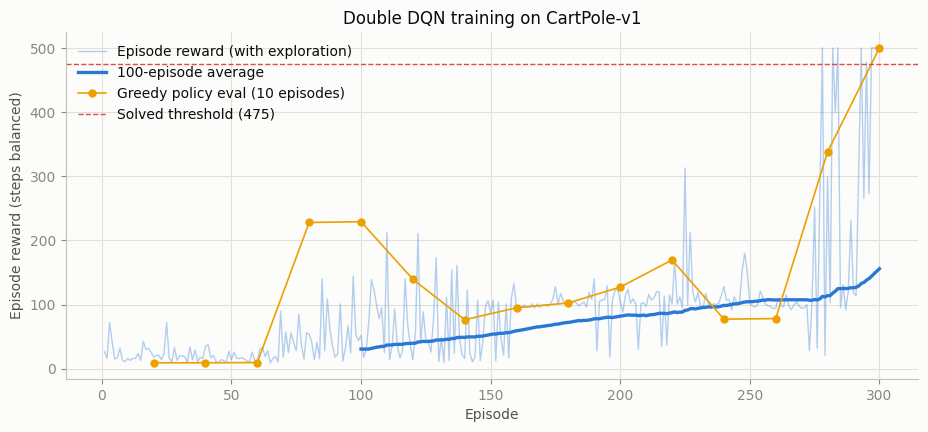

In [5]:
MAX_EPISODES, SOLVED_AT, EVAL_EVERY = 600, 475.0, 20


def greedy_eval(n=10):
    """Mean return of the greedy policy over n episodes (eval env)."""
    tot = []
    for _ in range(n):
        obs, _ = eval_env.reset()
        ep, done = 0.0, False
        while not done:
            obs, r, term, trunc, _ = eval_env.step(agent.act(obs, 0.0))
            done = term or trunc
            ep += r
        tot.append(ep)
    return float(np.mean(tot))


env.reset(seed=42)       # fresh, reproducible episode stream for training
eval_env.reset(seed=999)

gstep, rewards, eval_log = 0, [], []
best_score, best_weights, stop_reason = -1.0, None, "episode budget exhausted"
for ep in range(MAX_EPISODES):
    obs, _ = env.reset()
    ep_r, done = 0.0, False
    while not done:
        eps = max(EPS_END, 1.0 - (1 - EPS_END) * gstep / EPS_DECAY_STEPS)
        a = agent.act(obs, eps)
        obs2, r, term, trunc, _ = env.step(a)
        done = term or trunc
        agent.buf.add(obs, a, r, obs2, float(term))  # truncation is not death
        obs = obs2
        ep_r += r
        gstep += 1
        if agent.buf.n >= WARMUP:
            agent._train(*agent.buf.sample(agent.rng, BATCH))
    rewards.append(ep_r)
    avg100 = np.mean(rewards[-100:])
    if (ep + 1) % EVAL_EVERY == 0:
        ge = greedy_eval()
        eval_log.append((ep + 1, ge))
        if ge > best_score:
            best_score, best_weights = ge, agent.q.get_weights()
        print(f"episode {ep+1:3d} | reward {ep_r:5.0f} | "
              f"avg100 {avg100:6.1f} | greedy(10) {ge:5.1f} | "
              f"best {best_score:5.1f} | eps {eps:.2f}")
        if ge >= 500.0:
            stop_reason = f"perfect greedy evaluation at episode {ep + 1}"
            break
    if len(rewards) >= 100 and avg100 >= SOLVED_AT:
        stop_reason = (f"official criterion met during training at "
                       f"episode {ep + 1} (avg100 = {avg100:.1f})")
        break

print(f"\ntraining stopped: {stop_reason}")
print(f"{len(rewards)} episodes / {gstep} environment steps; "
      f"best greedy checkpoint: {best_score:.1f}")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(range(1, len(rewards) + 1), rewards, color=COLORS["blue"],
        alpha=0.35, linewidth=1, label="Episode reward (with exploration)")
ax.plot(range(1, len(rewards) + 1),
        pd.Series(rewards).rolling(100).mean(), color=COLORS["blue"],
        linewidth=2.4, label="100-episode average")
ax.plot(*zip(*eval_log), color=COLORS["yellow"], marker="o", markersize=5,
        linewidth=1.2, label="Greedy policy eval (10 episodes)")
ax.axhline(SOLVED_AT, color=COLORS["red"], linewidth=1, linestyle="--",
           label=f"Solved threshold ({SOLVED_AT:.0f})")
ax.set_xlabel("Episode")
ax.set_ylabel("Episode reward (steps balanced)")
ax.set_title("Double DQN training on CartPole-v1")
ax.legend(loc="upper left")
save_fig(fig, "02_training_progress.png")
plt.show()


## 4 — Checking the official solved criterion

The best checkpoint is run greedily (no exploration, no training) for 100
consecutive episodes and the average reward is compared with the 475
threshold.


100 consecutive greedy episodes: mean 500.0 | min 500 | max 500 | perfect (500-step) episodes: 100/100
Random policy baseline: mean 21.9

Official criterion: 500.0 >= 475 -> SOLVED


saved plot -> 03_state_traces.png


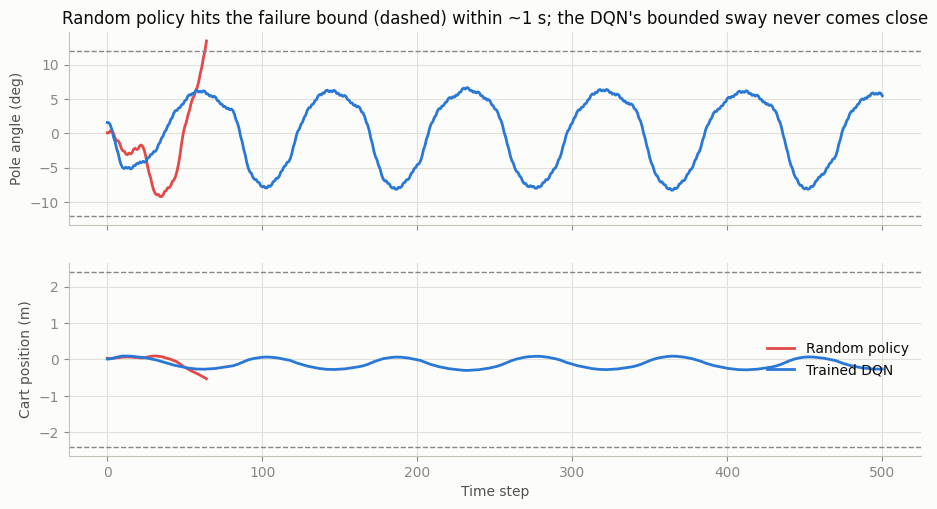

In [6]:
agent.q.set_weights(best_weights)   # restore the best checkpoint
agent.q_tgt.set_weights(best_weights)

cert_returns = []
for _ in range(100):                # 100 consecutive greedy episodes
    obs, _ = eval_env.reset()
    tot, done = 0.0, False
    while not done:
        obs, r, term, trunc, _ = eval_env.step(agent.act(obs, 0.0))
        done = term or trunc
        tot += r
    cert_returns.append(tot)

cert_returns = np.array(cert_returns)
mean_r = cert_returns.mean()
print(f"100 consecutive greedy episodes: mean {mean_r:.1f} | "
      f"min {cert_returns.min():.0f} | max {cert_returns.max():.0f} | "
      f"perfect (500-step) episodes: {(cert_returns == 500).sum()}/100")
print(f"Random policy baseline: mean {np.mean(random_returns):.1f}")
verdict = "SOLVED" if mean_r >= SOLVED_AT else "NOT solved"
print(f"\nOfficial criterion: {mean_r:.1f} >= {SOLVED_AT:.0f} -> {verdict}")

greedy_states = rollout(greedy, e=eval_env, seed=7)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ax1.plot(np.degrees(random_states[:, 2]), color=COLORS["red"],
         label="Random policy")
ax1.plot(np.degrees(greedy_states[:, 2]), color=COLORS["blue"],
         label="Trained DQN")
for b in (12, -12):
    ax1.axhline(b, color="#898781", linewidth=1, linestyle="--")
ax1.set_ylabel("Pole angle (deg)")
ax1.set_title("Random policy hits the failure bound (dashed) within ~1 s; "
              "the DQN's bounded sway never comes close")
ax2.plot(random_states[:, 0], color=COLORS["red"], label="Random policy")
ax2.plot(greedy_states[:, 0], color=COLORS["blue"], label="Trained DQN")
for b in (2.4, -2.4):
    ax2.axhline(b, color="#898781", linewidth=1, linestyle="--")
ax2.set_ylabel("Cart position (m)")
ax2.set_xlabel("Time step")
ax2.legend(loc="center right")
save_fig(fig, "03_state_traces.png")
plt.show()


## 5 — Disturbance test

To test balance against disturbances, the pole is kicked (±0.3 rad/s added
to its angular velocity) at steps 100, 200, 300 and 400. The controller has
to catch the pole and re-balance each time.


With 4 kicks of +/-0.3 rad/s: survived 500/500 steps - full recovery from every kick


saved plot -> 04_disturbance_test.png


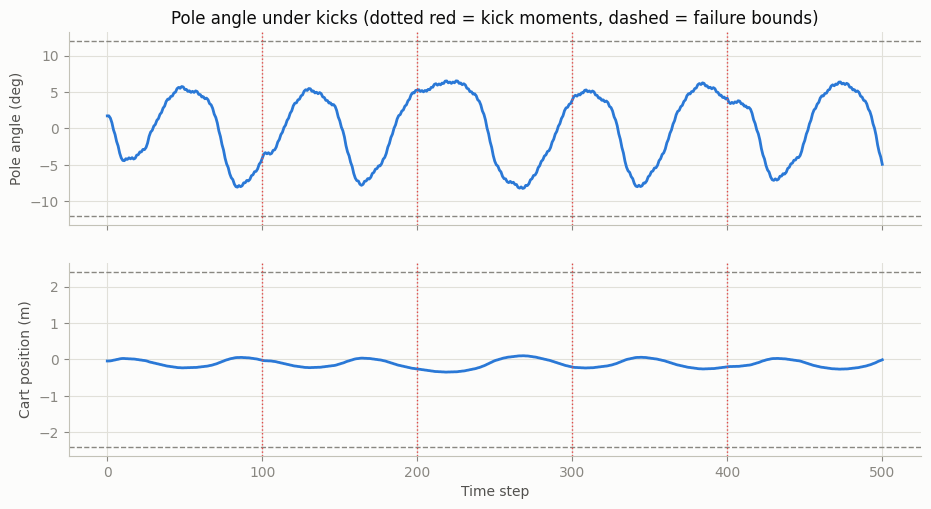

In [7]:
KICKS = {100: +0.3, 200: -0.3, 300: +0.3, 400: -0.3}
kicked_states = rollout(greedy, e=eval_env, seed=3, kicks=KICKS)
survived = len(kicked_states) - 1
print(f"With 4 kicks of +/-0.3 rad/s: survived {survived}/500 steps"
      + (" - full recovery from every kick" if survived == 500 else ""))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ax1.plot(np.degrees(kicked_states[:, 2]), color=COLORS["blue"])
for b in (12, -12):
    ax1.axhline(b, color="#898781", linewidth=1, linestyle="--")
for k in KICKS:
    ax1.axvline(k, color=COLORS["red"], linewidth=1, linestyle=":")
ax1.set_ylabel("Pole angle (deg)")
ax1.set_title("Pole angle under kicks (dotted red = kick moments, "
              "dashed = failure bounds)")
ax2.plot(kicked_states[:, 0], color=COLORS["blue"])
for b in (2.4, -2.4):
    ax2.axhline(b, color="#898781", linewidth=1, linestyle="--")
for k in KICKS:
    ax2.axvline(k, color=COLORS["red"], linewidth=1, linestyle=":")
ax2.set_ylabel("Cart position (m)")
ax2.set_xlabel("Time step")
save_fig(fig, "04_disturbance_test.png")
plt.show()


### Animation

The disturbance episode as a GIF at real-time speed — a red "kick!" flashes
at each disturbance. Saved as `06_animation.gif` next to the notebook.


saved animation -> 06_animation.gif


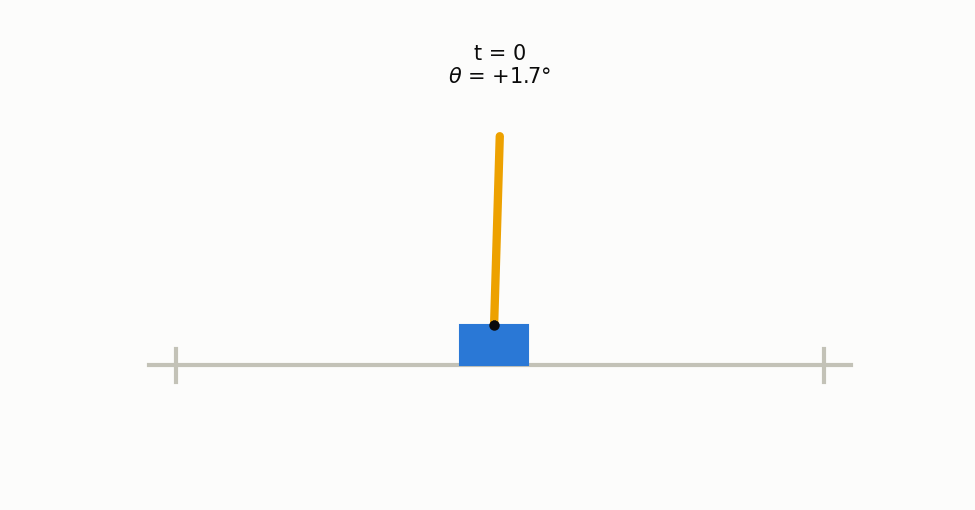

In [8]:
from IPython.display import Image as IPyImage
from matplotlib.animation import FuncAnimation, PillowWriter

fig_a, ax_a = plt.subplots(figsize=(6.5, 3.4), dpi=80)


def _frame(i):
    ax_a.clear()
    draw_cartpole(ax_a, kicked_states[i], t=i)
    if any(k <= i < k + 20 for k in KICKS):
        ax_a.annotate("kick!", xy=(kicked_states[i, 0] + 0.2, 1.6),
                      color=COLORS["red"], fontsize=13, fontweight="bold")


anim = FuncAnimation(fig_a, _frame, frames=range(0, len(kicked_states), 2))
anim.save("06_animation.gif", writer=PillowWriter(fps=25))
plt.close(fig_a)
print("saved animation -> 06_animation.gif")
IPyImage(filename="06_animation.gif")


saved plot -> 05_balanced_frames.png


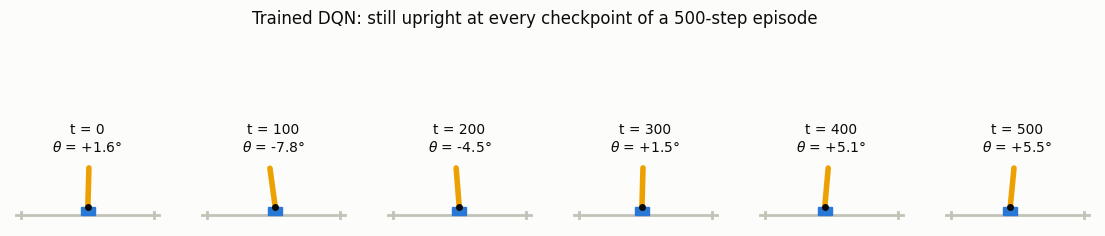

In [9]:
fig, axes = plt.subplots(1, 6, figsize=(14, 2.8))
for ax, i in zip(axes, np.linspace(0, len(greedy_states) - 1, 6).astype(int)):
    draw_cartpole(ax, greedy_states[i], t=i)
fig.suptitle("Trained DQN: still upright at every checkpoint of a "
             "500-step episode", y=1.15)
save_fig(fig, "05_balanced_frames.png")
plt.show()


## 6. Results

- Random policy: ~22 steps before the pole falls. Trained DQN: 500/500
  steps in all 100 evaluation episodes → **officially solved**
  (mean 500 ≥ 475).
- The pole sways about ±8° instead of standing perfectly still — with only
  two full-force pushes there is no way to make fine corrections, so the
  controller settles into a stable back-and-forth well inside the ±12°
  bound.
- The training curve is much noisier than the greedy evaluations because
  exploration stays on during training.
- The agent also recovers from all four kicks in the disturbance test.

